In [3]:
import os
import sys
from pathlib import Path

project_root = Path(os.getcwd()).resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print("Project root path setup complete!")

VISUALIZE_SPLIT = "train"

MODEL_NAME = "facebook/dinov2-small"
WEIGHTS_PATH = "runs/dinov2/best.pt"
NUM_CLASSES = 6


EVAL_IMAGES_DIR = "data/processed/val/images"
EVAL_LABELS_DIR = "data/processed/val/labels"

Project root path setup complete!


In [4]:

print("Running Harmonization Verification...")
exec(open('src/data/verify_harmonization.py').read())

Running Harmonization Verification...
  Harmonization Verification

[1] Folder structure...
  ✅ data/processed/train/images: 20763 files
  ✅ data/processed/train/labels: 20763 files
  ✅ data/processed/val/images: 3931 files
  ✅ data/processed/val/labels: 3931 files

[2] Class distribution...
  Total label files: 20763
  0 pothole                    10028 ████████████████████
  1 longitudinal_crack          8956 █████████████████
  2 transverse_crack            2518 █████
  3 alligator_crack             4890 █████████
  4 rutting                        0 
  5 surface_deterioration        696 █

[3] Image-label matching...
  ✅ train: 20763 matched, 0 unmatched
  ✅ val: 3931 matched, 0 unmatched

✅ Verification Complete!


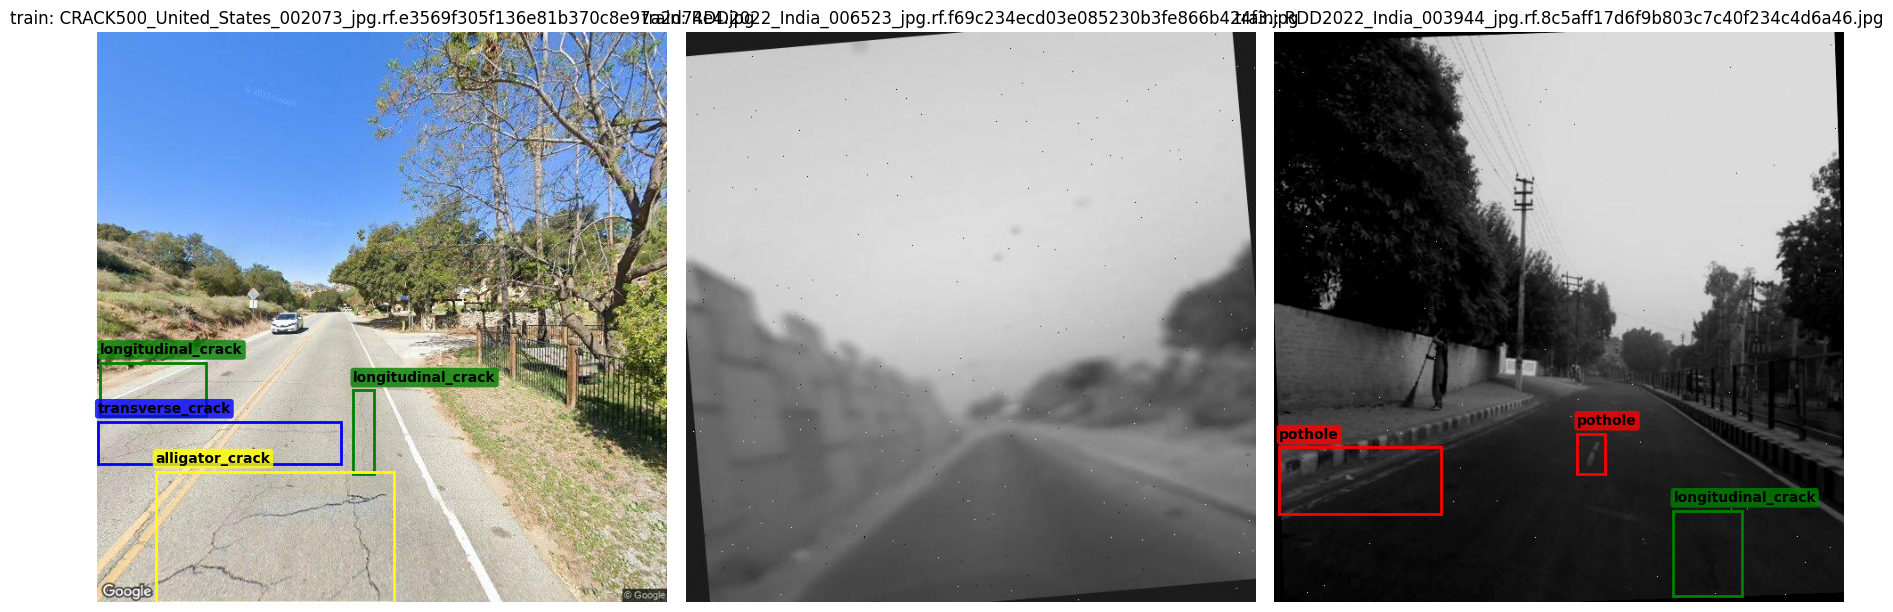

In [6]:
import random
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path

images_dir = Path(f"data/processed/{VISUALIZE_SPLIT}/images")
labels_dir = Path(f"data/processed/{VISUALIZE_SPLIT}/labels")

CLASSES = {
    0: "pothole", 
    1: "longitudinal_crack", 
    2: "transverse_crack",
    3: "alligator_crack", 
    4: "rutting", 
    5: "surface_deterioration"
}

COLOR_MAP = {
    0: "red",
    1: "green",
    2: "blue",
    3: "yellow",
    4: "magenta",
    5: "cyan"
}

all_images = list(images_dir.glob("*.jpg")) + list(images_dir.glob("*.png")) + list(images_dir.glob("*.jpeg"))
valid_pairs = []

for img_path in all_images:
    lbl_path = labels_dir / f"{img_path.stem}.txt"
    if lbl_path.exists():
        valid_pairs.append((img_path, lbl_path))

if len(valid_pairs) >= 3:
    samples = random.sample(valid_pairs, 3)
else:
    samples = valid_pairs

if not samples:
    print(f"No matched image-label pairs found in {VISUALIZE_SPLIT} directory!")
else:
    fig, axes = plt.subplots(1, len(samples), figsize=(6 * len(samples), 6))
    if len(samples) == 1:
        axes = [axes]
        
    for idx, (img_path, lbl_path) in enumerate(samples):
        ax = axes[idx]
        image = Image.open(img_path).convert("RGB")
        w, h = image.size
        ax.imshow(image)
        
        # Draw bounding boxes
        with open(lbl_path, "r") as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                parts = line.split()
                cls_id = int(parts[0])
                cx, cy, bw, bh = [float(x) for x in parts[1:5]]
                
                # Convert normalized YOLO coordinates back to pixels
                x1 = (cx - bw / 2) * w
                y1 = (cy - bh / 2) * h
                box_w = bw * w
                box_h = bh * h
                
                rect = patches.Rectangle(
                    (x1, y1), box_w, box_h, 
                    linewidth=2, 
                    edgecolor=COLOR_MAP.get(cls_id, "white"), 
                    facecolor="none"
                )
                ax.add_patch(rect)
                
                cls_name = CLASSES.get(cls_id, f"Class {cls_id}")
                ax.text(
                    x1, y1 - 10, cls_name, 
                    color="black", 
                    weight="bold", 
                    fontsize=10,
                    bbox=dict(facecolor=COLOR_MAP.get(cls_id, "white"), alpha=0.8, edgecolor="none", boxstyle="round,pad=0.2")
                )
                
        ax.set_title(f"{VISUALIZE_SPLIT}: {img_path.name}")
        ax.axis("off")
        
    plt.tight_layout()
    plt.show()

In [11]:
import torch
import numpy as np
from PIL import Image
from pathlib import Path
from transformers import AutoImageProcessor
from sklearn.metrics import roc_auc_score
from collections import defaultdict

from src.models.dinov2_model import DINOv2Detector

# Setup config
device = torch.device("mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu"))
print(f"Using device: {device}")

CLASSES = {
    0: "pothole",
    1: "longitudinal_crack",
    2: "transverse_crack",
    3: "alligator_crack",
    4: "rutting",
    5: "surface_deterioration"
}

# 1. Load model dynamically based on configuration
processor = AutoImageProcessor.from_pretrained(MODEL_NAME)
model = DINOv2Detector(
    model_name=MODEL_NAME,
    num_classes=NUM_CLASSES,
    freeze_backbone=True
).to(device)

if Path(WEIGHTS_PATH).exists():
    model.load_state_dict(torch.load(WEIGHTS_PATH, map_location=device))
    model.eval()
    print(f"Model loaded successfully from {WEIGHTS_PATH}!")
else:
    print(f"WARNING: Weights file not found at {WEIGHTS_PATH}! Evaluating untrained model.")

# 2. Load ground truth presence of damage
gt_dict = {}
for lbl_file in Path(EVAL_LABELS_DIR).glob("*.txt"):
    classes = []
    with open(lbl_file, "r") as f:
        for line in f.readlines():
            line = line.strip()
            if line:
                cls = int(line.split()[0])
                classes.append(cls)
    gt_dict[lbl_file.stem] = classes

# 3. Predict presence scores
images = list(Path(EVAL_IMAGES_DIR).glob("*.jpg")) + list(Path(EVAL_IMAGES_DIR).glob("*.png")) + list(Path(EVAL_IMAGES_DIR).glob("*.jpeg"))
per_class_gt = defaultdict(list)
per_class_scores = defaultdict(list)

print(f"Running inference on {len(images)} evaluation images in {EVAL_IMAGES_DIR}...")
for img_path in images:
    img_name = img_path.stem
    image = Image.open(img_path).convert("RGB")
    encoding = processor(images=image, return_tensors="pt")
    pixels = encoding["pixel_values"].to(device)
    
    with torch.no_grad():
        outputs = model(pixels)
        
    logits = outputs["logits"][0]
    probs = torch.softmax(logits, dim=-1)
    scores, labels = probs[:, :-1].max(dim=-1)
    
    max_score = scores.max().item() if len(scores) > 0 else 0.0
    
    class_scores = defaultdict(float)
    for score, label in zip(scores.tolist(), labels.tolist()):
        cls = int(label)
        class_scores[cls] = max(class_scores[cls], score)
        
    gt = gt_dict.get(img_name, [])
    
    for cls_id in range(6):
        per_class_gt[cls_id].append(1 if cls_id in gt else 0)
        per_class_scores[cls_id].append(class_scores.get(cls_id, 0.0))

print("\n" + "=" * 50)
print(f"  Presence AUROC Results on {EVAL_IMAGES_DIR}")
print("=" * 50)

print("\n  Per-Class AUROC:")
print("  " + "-" * 40)
for cls_id in range(6):
    gt_arr = np.array(per_class_gt[cls_id])
    score_arr = np.array(per_class_scores[cls_id])
    if len(np.unique(gt_arr)) > 1:
        auroc = roc_auc_score(gt_arr, score_arr)
        print(f"  {CLASSES[cls_id]:<25} AUROC: {auroc:.4f}")
    else:
        print(f"  {CLASSES[cls_id]:<25} AUROC: N/A (Insufficient class samples)")
print("=" * 50)

Using device: mps
[INFO] Loading DINOv2: facebook/dinov2-small
[INFO] Hidden size: 384
[INFO] Backbone frozen — only training detection head
Model loaded successfully from runs/dinov2/best.pt!
Running inference on 3931 evaluation images in data/processed/val/images...

  Presence AUROC Results on data/processed/val/images

  Per-Class AUROC:
  ----------------------------------------
  pothole                   AUROC: 0.6198
  longitudinal_crack        AUROC: 0.8001
  transverse_crack          AUROC: 0.6257
  alligator_crack           AUROC: 0.6875
  rutting                   AUROC: N/A (Insufficient class samples)
  surface_deterioration     AUROC: 0.6762


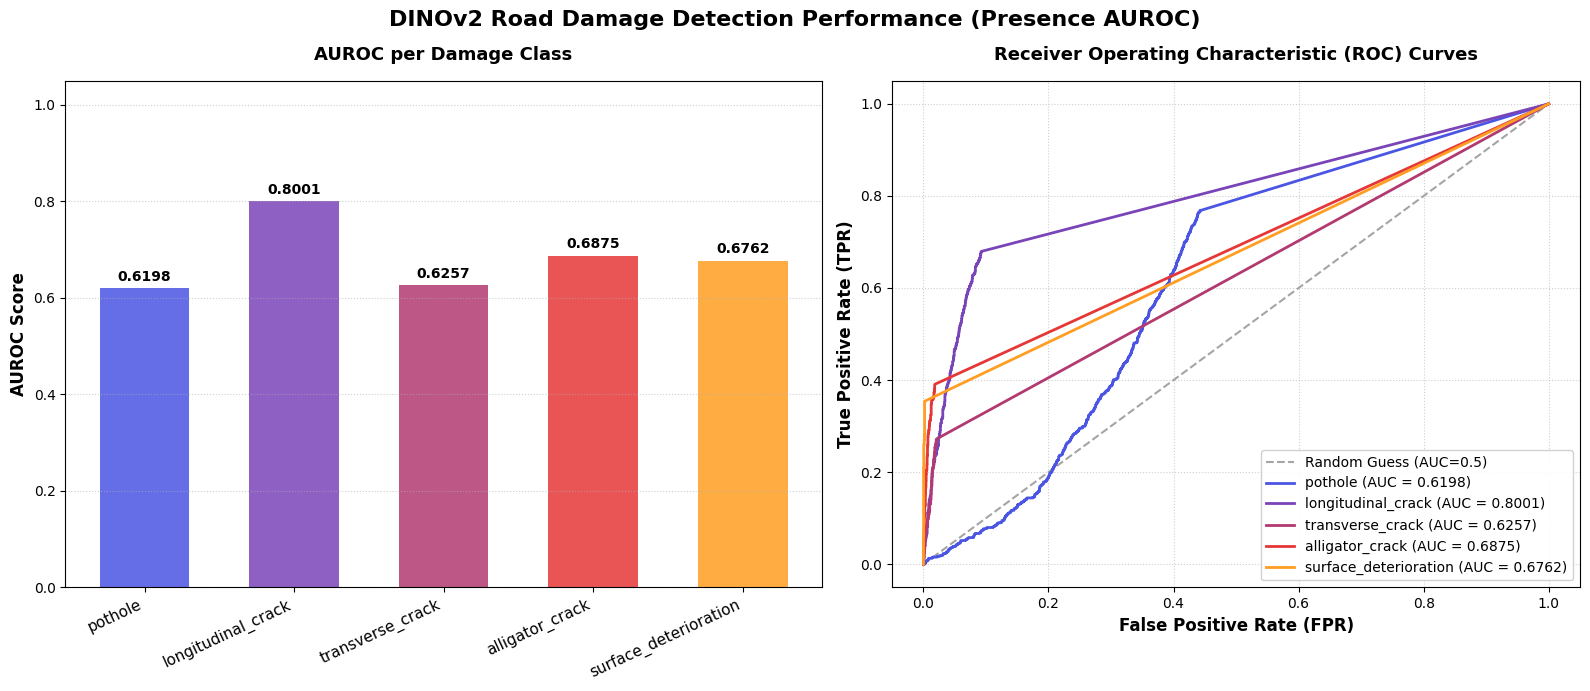

In [12]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, roc_auc_score

# 1. Gather class names and compute ROC curves/AUROC data
class_names = []
class_aurocs = []
roc_curves = {}

# Compute per-class ROCs
for cls_id, cls_name in CLASSES.items():
    if cls_id == 4:
        continue
    gt_arr = np.array(per_class_gt[cls_id])
    score_arr = np.array(per_class_scores[cls_id])
    class_names.append(cls_name)
    
    if len(np.unique(gt_arr)) > 1:
        fpr, tpr, _ = roc_curve(gt_arr, score_arr)
        auroc = roc_auc_score(gt_arr, score_arr)
        roc_curves[cls_name] = (fpr, tpr, auroc)
        class_aurocs.append(auroc)
    else:
        class_aurocs.append(None)  # Insufficient samples

# 2. Setup figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), gridspec_kw={'width_ratios': [1.1, 1]})
fig.suptitle("DINOv2 Road Damage Detection Performance (Presence AUROC)", fontsize=16, fontweight='bold', y=0.98)

# The specified color palette from the image
colors = [
    '#4B55E3',  # Blue-purple (pothole, class 0)
    '#7A44B9',  # Purple (longitudinal_crack, class 1)
    '#B23A70',  # Reddish-pink (transverse_crack, class 2)
    '#E63737',  # Red (alligator_crack, class 3)
    '#F15B24',  # Orange (rutting, class 4 - skipped)
    '#FF9E22'   # Yellow-orange (surface_deterioration, class 5)
]
# Map each class to its designated color by original class ID
color_map = {}
for cls_id, cls_name in CLASSES.items():
    if cls_id != 4:
        color_map[cls_name] = colors[cls_id]

# ----- Plot 1: Per-Class AUROC Bar Chart -----
bar_positions = np.arange(len(class_names))
bar_heights = [val if val is not None else 0.0 for val in class_aurocs]
bars = ax1.bar(bar_positions, bar_heights, color=[color_map[name] for name in class_names], alpha=0.85, width=0.6)

# Formatting Bar Chart
ax1.set_xticks(bar_positions)
ax1.set_xticklabels(class_names, rotation=25, ha='right', fontsize=11)
ax1.set_ylabel("AUROC Score", fontsize=12, fontweight='semibold')
ax1.set_title("AUROC per Damage Class", fontsize=13, fontweight='semibold', pad=15)
ax1.set_ylim(0, 1.05)
ax1.grid(axis='y', linestyle=':', alpha=0.6)

# Annotate values on top of the bars
for bar, val in zip(bars, class_aurocs):
    if val is not None:
        ax1.text(bar.get_x() + bar.get_width()/2., val + 0.01, f"{val:.4f}",
                 ha='center', va='bottom', fontsize=10, fontweight='bold')
    else:
        ax1.text(bar.get_x() + bar.get_width()/2., 0.05, "N/A\n(No Samples)",
                 ha='center', va='bottom', color='gray', fontsize=9, style='italic')

# ----- Plot 2: ROC Curves -----
# Reference diagonal (random guess)
ax2.plot([0, 1], [0, 1], color='#A5A5A5', linestyle='--', linewidth=1.5, label='Random Guess (AUC=0.5)')

# Plot per-class ROC curves
for cls_name, curve_data in roc_curves.items():
    fpr, tpr, auroc = curve_data
    ax2.plot(fpr, tpr, color=color_map.get(cls_name, '#000000'), linewidth=2, label=f"{cls_name} (AUC = {auroc:.4f})")

# Formatting ROC Curves Plot
ax2.set_xlabel("False Positive Rate (FPR)", fontsize=12, fontweight='semibold')
ax2.set_ylabel("True Positive Rate (TPR)", fontsize=12, fontweight='semibold')
ax2.set_title("Receiver Operating Characteristic (ROC) Curves", fontsize=13, fontweight='semibold', pad=15)
ax2.legend(loc='lower right', fontsize=10, frameon=True, facecolor='white', framealpha=0.9)
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()
